In [6]:
import os
os.getcwd()

'C:\\Users\\hasan\\Documents\\Python\\ml25\\machine-learning-internship-projects\\project-07-spam-email-classifier(NLP)\\notebooks'

In [9]:
import pandas as pd

df = pd.read_csv("../data/raw/spam.tsv", sep="\t", header=None)
df.columns = ["label", "text"]

df.head()
df.shape
df.info()
df.head(10)
df.tail(10)
df.isnull().sum()
df['label'].value_counts()
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


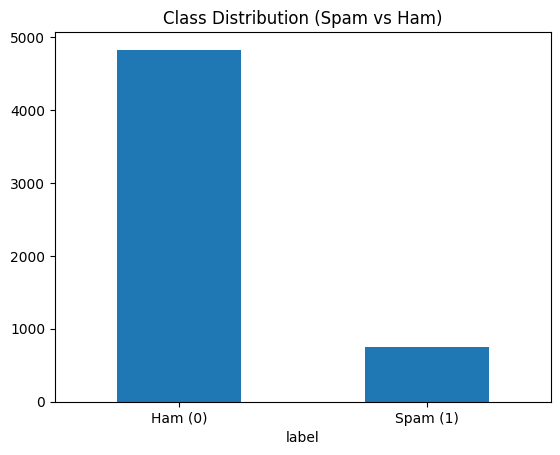

In [11]:
df['label'].value_counts()
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Spam vs Ham)")
plt.xticks([0,1], ['Ham (0)', 'Spam (1)'], rotation=0)
plt.savefig("../reports/figures/class_distribution.png")
plt.show()

In [13]:
df['length'] = df['text'].apply(len)
df['length'].describe()
df.groupby('label')['length'].mean()


label
0     71.482487
1    138.670683
Name: length, dtype: float64

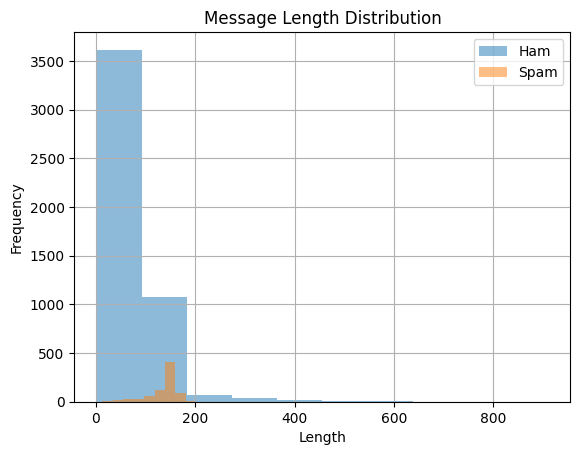

In [14]:
import matplotlib.pyplot as plt

df[df['label']==0]['length'].hist(alpha=0.5, label='Ham')
df[df['label']==1]['length'].hist(alpha=0.5, label='Spam')

plt.legend()
plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.savefig("../reports/figures/length_distribution.png")
plt.show()

In [15]:
from collections import Counter
import re

def get_words(text):
    text = text.lower()
    words = re.findall(r'\b\w+\b', text)
    return words

# Separate spam and ham
spam_words = []
ham_words = []

for text in df[df['label'] == 1]['text']:
    spam_words.extend(get_words(text))

for text in df[df['label'] == 0]['text']:
    ham_words.extend(get_words(text))

# Count frequencies
spam_common = Counter(spam_words).most_common(20)
ham_common = Counter(ham_words).most_common(20)

spam_common, ham_common

([('to', 691),
  ('a', 380),
  ('call', 355),
  ('you', 297),
  ('your', 264),
  ('free', 224),
  ('2', 207),
  ('the', 206),
  ('for', 204),
  ('now', 199),
  ('or', 188),
  ('u', 174),
  ('txt', 163),
  ('is', 158),
  ('on', 145),
  ('ur', 144),
  ('4', 137),
  ('have', 135),
  ('from', 131),
  ('mobile', 127)],
 [('i', 2960),
  ('you', 1948),
  ('to', 1562),
  ('the', 1133),
  ('a', 1070),
  ('u', 1033),
  ('and', 858),
  ('in', 823),
  ('me', 777),
  ('my', 754),
  ('is', 739),
  ('it', 718),
  ('that', 560),
  ('of', 526),
  ('for', 507),
  ('s', 490),
  ('have', 443),
  ('can', 441),
  ('but', 441),
  ('so', 436)])

In [16]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_words(text):
    text = text.lower()
    words = re.findall(r'\b\w+\b', text)
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return words

# Recompute
spam_words = []
ham_words = []

for text in df[df['label'] == 1]['text']:
    spam_words.extend(get_words(text))

for text in df[df['label'] == 0]['text']:
    ham_words.extend(get_words(text))

spam_common = Counter(spam_words).most_common(20)
ham_common = Counter(ham_words).most_common(20)

spam_common, ham_common

([('free', 224),
  ('2', 207),
  ('u', 174),
  ('txt', 163),
  ('ur', 144),
  ('4', 137),
  ('mobile', 127),
  ('text', 125),
  ('stop', 123),
  ('claim', 113),
  ('1', 111),
  ('reply', 104),
  ('www', 98),
  ('prize', 93),
  ('t', 92),
  ('s', 90),
  ('just', 79),
  ('cash', 76),
  ('won', 76),
  ('uk', 74)],
 [('u', 1033),
  ('s', 490),
  ('m', 411),
  ('t', 397),
  ('2', 326),
  ('gt', 318),
  ('lt', 316),
  ('just', 297),
  ('ok', 288),
  ('ll', 266),
  ('ur', 247),
  ('know', 237),
  ('good', 235),
  ('like', 234),
  ('got', 233),
  ('come', 230),
  ('day', 212),
  ('love', 205),
  ('time', 202),
  ('4', 190)])